# 00 · Fashion Dataset Exploratory Data Analysis

## Purpose

This notebook is the single evidence base for every downstream modelling decision in
notebook `01`. It runs seven audits against the **raw, unmodified** files in `data/train/`
and reports what they show, including the parts that are inconvenient. It does **not**
clean the data, does **not** assign a train/validation/test split, and does **not** call
`train_test_split`. The only file this notebook writes is
`results/figures/dataset_overview.png` — a single report-candidate composite figure.

## The seven audits

1. **Schema audit** — physical CSV structure, phantom columns, blank/missing counts, the
   literal string `"NA"` versus true blanks in `usage`.
2. **Image integrity audit** — every training image's dimensions, colour mode, corruption
   status, and content hashes.
3. **ID reconciliation** — which CSV rows have no matching image file and vice versa.
4. **Exact-duplicate detection** — byte-identical and pixel-identical image groups.
5. **Near-duplicate candidate detection** — perceptual-hash (`dhash`) components that
   *may* represent visual duplicates, always treated as review candidates, never as
   confirmed duplicates.
6. **Target distribution, hierarchy, and association audit** — class balance for
   `articleType`, `season`, `gender`, `usage`; `articleType` → `masterCategory`/
   `subCategory` hierarchy conflicts; and the `gender`×`usage` association strength.
7. **Split-feasibility and open-decision audit** — which classes have enough support to
   appear in both a training and an evaluation partition, and which policy questions the
   evidence leaves unresolved for notebook `01` to decide.

The audits above are numbered independently of the section headings below. Audits 1–3 are
reported in Section 2, audit 4 in Section 3.1, audit 5 in Sections 3.2, 3.3 and 5.6,
audit 6 in Section 4, and audit 7 in Section 6. Section 5 is the stratified visual review
that supplies the human-judgement evidence for audits 5–7, and Section 7 holds the saved
composite figure and the decision ledger.

## Boundaries

- **No cleaning.** Corrupt images, blank labels, and phantom columns are counted and
  displayed, never dropped or imputed here.
- **Two populations, never mixed silently.** `styles` is all 38,617 CSV rows and describes
  the annotations; `usable_styles` is the 38,612 rows whose image file exists and decodes,
  and is the only population used for anything that needs pixels — visual grids and every
  split-feasibility count. Section 2.2 defines it and Section 6 reports both counts side by
  side, because the five-row gap removes an entire `articleType` class.
- **No splitting.** No function in this notebook or in `fashion.eda` assigns a partition;
  `data/processed/splits.csv` does not exist yet and this notebook does not create it.
- **Fixed seed.** All sampling uses `RANDOM_SEED = 2753` from `fashion.config`, so every
  image grid below is reproducible.
- **Macro-F1 framing.** Because every target is class-imbalanced (see Section 5), the
  project reports macro-F1 as the primary classification metric in later notebooks;
  majority-class accuracy is calculated here only as a sanity floor, not as a target.
- **Candidates, not conclusions.** Perceptual near-duplicate groups are transitive
  connected components over a distance threshold — they are *review candidates*. Only a
  human visually confirming a group makes it an atomic duplicate group for splitting.

## 1. Environment

In [1]:
%matplotlib inline
from importlib.metadata import version

import matplotlib.pyplot as plt
import pandas as pd

from fashion.config import (
    FIGURE_DIR,
    RANDOM_SEED,
    TARGET_COLUMNS,
    TRAIN_CSV,
    TRAIN_IMAGE_DIR,
)
from fashion.eda import (
    audit_csv,
    audit_images,
    build_dataset_overview,
    cooccurrence_table,
    cramers_v,
    exact_duplicate_groups,
    hierarchy_conflicts,
    near_duplicate_groups,
    plot_image_grid,
    reconcile_ids,
    sample_ids,
    target_distribution,
    target_summary,
)

pd.set_option("display.max_rows", 130)
VERSIONS = {
    package: version(package)
    for package in ("pandas", "numpy", "matplotlib", "pillow", "jupyter")
}
VERSIONS

{'pandas': '3.0.5',
 'numpy': '2.5.2',
 'matplotlib': '3.11.1',
 'pillow': '12.3.0',
 'jupyter': '1.1.1'}

## 2. Schema and Image-Integrity Audit

We audit the raw CSV and the raw image directory independently, then reconcile their IDs.
`audit_csv` reads with `keep_default_na=False` so the literal string `"NA"` in `usage`
is never silently converted to a missing value. It also reconstructs `productDisplayName`
in memory from any comma-spilled phantom (`Unnamed:`) columns — the physical file is never
rewritten.

In [2]:
styles, schema_audit = audit_csv(TRAIN_CSV)
images = audit_images(TRAIN_IMAGE_DIR)
id_reconciliation = reconcile_ids(styles, images)

assert schema_audit.row_count == len(styles)
assert len(schema_audit.phantom_columns) == 2
assert schema_audit.blank_counts["usage"] != schema_audit.literal_na_usage_count
assert len(images) == images["id"].nunique()
assert id_reconciliation.matched_count + len(id_reconciliation.csv_only_ids) == styles["id"].nunique()
print("All Section 2 invariants hold.")

All Section 2 invariants hold.


### 2.1 Schema fields

In [3]:
schema_fields = pd.DataFrame(
    {
        "field": [
            "row_count",
            "physical_columns",
            "phantom_columns",
            "phantom_nonempty_counts",
            "duplicate_ids",
            "literal_na_usage_count",
        ],
        "value": [
            schema_audit.row_count,
            schema_audit.physical_columns,
            schema_audit.phantom_columns,
            schema_audit.phantom_nonempty_counts,
            schema_audit.duplicate_ids,
            schema_audit.literal_na_usage_count,
        ],
    }
)
with pd.option_context("display.max_colwidth", None):
    print(schema_fields.to_string(index=False))

                  field                                                                                                                                 value
              row_count                                                                                                                                 38617
       physical_columns (id, gender, masterCategory, subCategory, articleType, baseColour, season, year, usage, productDisplayName, Unnamed: 10, Unnamed: 11)
        phantom_columns                                                                                                            (Unnamed: 10, Unnamed: 11)
phantom_nonempty_counts                                                                                                 {'Unnamed: 10': 21, 'Unnamed: 11': 2}
          duplicate_ids                                                                                                                                    ()
 literal_na_usage_count                             

In [4]:
blank_counts = (
    pd.Series(schema_audit.blank_counts, name="blank_count")
    .rename_axis("column")
    .reset_index()
    .sort_values("blank_count", ascending=False, ignore_index=True)
)
blank_counts

,column,blank_count
0,season,20
1,usage,1
2,id,0
3,gender,0
4,masterCategory,0
5,subCategory,0
6,articleType,0
7,baseColour,0
8,year,0
9,productDisplayName,0


**Interpretation (feeds notebook `01`).** The CSV parses to the expected row count with
no duplicate `id` values, so row identity is trustworthy. Two phantom `Unnamed:` columns
exist in the physical header and some rows spill real text into them — `audit_csv` folds
that overflow back into `productDisplayName` in memory rather than discarding it, and the
non-empty counts above are the exact size of that overflow. `productDisplayName` is
free text and is **not** one of the four assignment targets, so this overflow does not
threaten label quality; it only means any later text-based work must use the
reconstructed column, not the raw physical one. Blank counts are target-specific: `season`
has 20 blank rows and `usage` has exactly one — quite different from the 71 rows holding
the literal string `"NA"` in `usage`, confirmed distinct by the assertion above.
Notebook `01` must not conflate "blank" with "the annotator's genuine NA label" when
deciding whether to drop or keep a row for a given target.

### 2.2 Image integrity and ID reconciliation

`audit_images` opens every file in `data/train/images_train/`, so the next cell reads all
training images once — expect this cell to take a few minutes.

In [5]:
corrupt_images = images.loc[images["error"].ne(""), ["id", "path", "error"]]
dimension_mode_counts = (
    images.groupby(["width", "height", "mode"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False, ignore_index=True)
)
print(f"Readable images: {images['error'].eq('').sum():,} / {len(images):,}")
corrupt_images

Readable images: 38,612 / 38,612


,id,path,error


In [6]:
dimension_mode_counts

,width,height,mode,count
0,60,80,RGB,38252
1,60,80,L,343
2,53,80,RGB,8
3,60,60,RGB,5
4,60,77,RGB,2
5,60,75,RGB,1
6,60,76,RGB,1


**Interpretation.** All 38,612 files in the training image directory decoded
successfully: `corrupt_images` is empty and there are zero read failures. That is an
observation about *this* directory, not a property of the dataset — the
corruption-handling branch in `audit_images` therefore ran zero times and remains
untested against real data, so the held-out images in `data/test/` must be audited the
same way before any loader assumes they are all readable.

The supplied "60×80" description is close but not exact. 38,252 files are 60×80 RGB, 343
are 60×80 grayscale `L`, and 17 more are spread across five other sizes (53×80, 60×60,
60×77, 60×76, 60×75). So 360 files — just under 1% — violate one of the two assumptions a
naive loader would make. Preprocessing must resize to one canonical shape *and* convert
mode explicitly; a pipeline that assumes three channels will fail on the 343 grayscale
files rather than silently mishandling them.

In [7]:
unmatched_ids = pd.DataFrame(
    {
        "kind": ["csv_only (no image file)", "image_only (no CSV row)"],
        "count": [len(id_reconciliation.csv_only_ids), len(id_reconciliation.image_only_ids)],
        "ids": [id_reconciliation.csv_only_ids, id_reconciliation.image_only_ids],
    }
)
with pd.option_context("display.max_colwidth", None):
    print(unmatched_ids.to_string(index=False))

                    kind  count                                 ids
csv_only (no image file)      5 (12347, 39401, 39403, 39410, 39425)
 image_only (no CSV row)      0                                  ()


In [8]:
reconciliation_summary = pd.DataFrame(
    {
        "metric": [
            "csv rows (unique ids)",
            "image files",
            "matched ids",
            "csv-only ids",
            "image-only ids",
        ],
        "count": [
            styles["id"].nunique(),
            len(images),
            id_reconciliation.matched_count,
            len(id_reconciliation.csv_only_ids),
            len(id_reconciliation.image_only_ids),
        ],
    }
)
reconciliation_summary

,metric,count
0,csv rows (unique ids),38617
1,image files,38612
2,matched ids,38612
3,csv-only ids,5
4,image-only ids,0


In [9]:
# The population every image-dependent statement in this notebook is allowed to use:
# a CSV row whose id matches a file that actually decoded.
usable_image_ids = set(images.loc[images["error"].eq(""), "id"].astype(str))
usable_styles = styles.loc[styles["id"].astype(str).isin(usable_image_ids)].copy()
unusable_styles = styles.loc[~styles["id"].astype(str).isin(usable_image_ids)]

# `matched_count` counts ids present in both the CSV and the image directory, whether or
# not the file decoded, so it is not the usable-row count: a matched id whose file is
# corrupt is matched and unusable at the same time. Splitting the two makes a future
# corrupt file a number this cell reports rather than an assertion that fails opaquely.
corrupt_image_ids = set(images.loc[images["error"].ne(""), "id"].astype(str))
matched_unreadable_ids = sorted(corrupt_image_ids.intersection(styles["id"].astype(str)))

assert len(usable_styles) + len(matched_unreadable_ids) == id_reconciliation.matched_count
assert len(usable_styles) + len(unusable_styles) == len(styles)

print(f"raw CSV rows:    {len(styles):,}")
print(f"usable rows:     {len(usable_styles):,}  (matched id and readable image)")
print(
    f"unusable rows:   {len(unusable_styles):,}  "
    f"({len(id_reconciliation.csv_only_ids):,} with no image file, "
    f"{len(matched_unreadable_ids):,} with a matched but unreadable image)"
)
if matched_unreadable_ids:
    print(f"matched but unreadable ids: {', '.join(matched_unreadable_ids)}")
print(
    f"articleType classes: {styles['articleType'].nunique()} raw -> "
    f"{usable_styles['articleType'].nunique()} usable"
)

lost_classes = sorted(
    set(styles["articleType"]).difference(usable_styles["articleType"])
)
print(f"articleType labels left with zero usable images: {lost_classes}")
with pd.option_context("display.max_colwidth", None):
    print("\n-- every row with no usable image --")
    print(
        unusable_styles[
            ["id", "gender", "masterCategory", "subCategory", "articleType",
             "season", "usage", "productDisplayName"]
        ].to_string(index=False)
    )

raw CSV rows:    38,617
usable rows:     38,612  (matched id and readable image)
unusable rows:   5  (5 with no image file, 0 with a matched but unreadable image)
articleType classes: 125 raw -> 124 usable
articleType labels left with zero usable images: ['Suits']

-- every row with no usable image --
   id gender masterCategory subCategory articleType season  usage                                           productDisplayName
12347    Men        Apparel     Topwear       Suits Winter Casual    Fastrack Men Red Manhattan Regular Fit Solid Formal Shirt
39401    Men        Apparel  Bottomwear       Jeans Winter Casual   U.S. Polo Assn. Denim Co. Men Blue Slim Straight Fit Jeans
39403    Men        Apparel     Topwear      Shirts Summer Casual          U.S. Polo Assn. Men Black Tailored Fit Casual Shirt
39410    Men        Apparel     Topwear      Shirts Summer Casual U.S. Polo Assn. Men Cream-Coloured Tailored Fit Casual Shirt
39425    Men        Apparel     Topwear     Tshirts Spring Cas

**Interpretation (feeds notebook `01`).** The `ids` column above is the complete,
non-truncated tuple of every mismatched ID in each direction — not a sample — so notebook
`01` can exclude exactly these rows from any image-dependent computation without
re-deriving them. There are no `image_only` IDs: every file has a label, so no orphan
images exist to guard against.

The five `csv_only` rows name metadata that **cannot** train or evaluate an image model no
matter how clean its labels are. That is why `usable_styles` exists and why the rest of
this notebook uses it for anything image-dependent: five rows out of 38,617 sounds
negligible until you notice *which* five. Id `12347` is the only `Suits` row in the
dataset, so on the raw frame `Suits` looks like a learnable singleton class, and on the
usable frame it has nothing at all. Rounding that difference away would put an
impossible-to-learn class into a split-design table as merely "hard".

Those rows are still legitimate evidence for text-only summaries — Section 4 deliberately
reports raw label distributions, because a labelling inconsistency in the CSV is real
whether or not the image survived. The rule is narrower than "drop these rows": use
`styles` to describe the annotations, and `usable_styles` for anything that needs pixels.

## 3. Exact and Candidate Near-Duplicate Detection

Three hash families answer three different questions: `byte_sha256` catches literal file
copies, `pixel_sha256` catches re-encodings of the same decoded pixels, and `dhash` (a
64-bit perceptual hash) links images that merely *look* similar. Only the first two are
proof of duplication; the third is a **review candidate**, never an automatic verdict.

In [10]:
byte_duplicate_groups = exact_duplicate_groups(images, "byte_sha256")
pixel_duplicate_groups = exact_duplicate_groups(images, "pixel_sha256")
near_groups = near_duplicate_groups(images, max_distance=6)

duplicate_summary = pd.DataFrame(
    {
        "kind": ["byte-identical", "pixel-identical", "near-duplicate candidate"],
        "groups": [
            len(byte_duplicate_groups),
            len(pixel_duplicate_groups),
            len(near_groups),
        ],
        "images": [
            sum(map(len, byte_duplicate_groups)),
            sum(map(len, pixel_duplicate_groups)),
            sum(map(len, near_groups)),
        ],
    }
)
duplicate_summary

,kind,groups,images
0,byte-identical,636,1399
1,pixel-identical,636,1399
2,near-duplicate candidate,448,33131


### 3.1 Confirmed exact duplicates

In [11]:
byte_equals_pixel = byte_duplicate_groups == pixel_duplicate_groups
print(f"byte-identical groups == pixel-identical groups: {byte_equals_pixel}")

exact_groups_table = pd.DataFrame(
    {
        "group_index": range(len(pixel_duplicate_groups)),
        "size": [len(group) for group in pixel_duplicate_groups],
        "ids": pixel_duplicate_groups,
    }
)
# Printed in full: the brief requires every confirmed group's IDs, and the default
# display option would elide all but the first and last few rows.
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    print(exact_groups_table.to_string(index=False))

byte-identical groups == pixel-identical groups: True
 group_index  size                          ids
           0     2               (10184, 10185)
           1     2               (10186, 10187)
           2     2               (10188, 10189)
           3     2               (10200, 10244)
           4     2               (10641, 10642)
           5     2               (10643, 10644)
           6     2               (10645, 10646)
           7     2               (10654, 10655)
           8     2               (10683, 10684)
           9     2               (11041, 11042)
          10     2               (11043, 11044)
          11     2               (11045, 11046)
          12     2               (11047, 11048)
          13     2               (11049, 11050)
          14     2               (11051, 11052)
          15     2               (11053, 11054)
          16     2               (11055, 11056)
          17     2               (11057, 11058)
          18     2               (

**Interpretation.** The two groupings are identical: the byte-level and pixel-level
partitions are equal, printed as `True` above. Every duplicate in this dataset is a
straight file copy, and no pair matches only after decoding — so re-encoded duplicates,
which would show up as pixel groups without a byte counterpart, do not occur here. The
636 groups cover 1,399 images and range from 2 to 4 members (512 pairs, 121 triples, 3
quadruples). Because these images are provably identical at the byte level, they are
**confirmed** duplicates, not candidates: notebook `01` must treat every group in
`exact_groups_table` as one atomic unit for split assignment, so no two members ever land
on opposite sides of a train/validation/held-out boundary.

### 3.2 Near-duplicate candidates — size distribution

A near-duplicate "group" here is a **connected component**: if A is close to B and B is
close to C, all three land in one group even if A and C are far apart (see the
`near_duplicate_groups` docstring). Before looking at individual images we first check
whether that transitive chaining has produced a distorted picture.

In [12]:
near_groups_by_size = sorted(near_groups, key=len, reverse=True)
size_histogram = (
    pd.Series([len(group) for group in near_groups_by_size], name="group_size")
    .value_counts()
    .rename_axis("group_size")
    .reset_index(name="num_groups")
    .sort_values("group_size", ignore_index=True)
)
size_histogram

,group_size,num_groups
0,2,308
1,3,71
2,4,28
3,5,9
4,6,12
5,7,5
6,8,3
7,9,2
8,10,2
9,14,2


In [13]:
giant_component = near_groups_by_size[0]
# The id set is built once: rebuilding it inside the comprehension cost one full pass over
# `styles` for each of the component's tens of thousands of members.
styles_by_id = styles.set_index("id")
known_ids = set(styles_by_id.index)
giant_members = styles_by_id.reindex([i for i in giant_component if i in known_ids])
giant_span = pd.DataFrame(
    {
        "metric": ["component_size", "distinct_articleType", "distinct_masterCategory", "distinct_baseColour"],
        "value": [
            len(giant_component),
            giant_members["articleType"].nunique(),
            giant_members["masterCategory"].nunique(),
            giant_members["baseColour"].nunique(),
        ],
    }
)
giant_span

,metric,value
0,component_size,31568
1,distinct_articleType,115
2,distinct_masterCategory,6
3,distinct_baseColour,47


**Interpretation.** The feared chaining failure did occur, and the histogram shows it
plainly. 308 components are pairs, 71 are triples, and the distribution then thins out to
a handful of groups in the 20–189 range — and then jumps to a single component of 31,568
images. That one component holds 81.8% of all readable images and 95.3% of every image
the scan linked to anything at all; the second-largest is 189, a factor of 167 smaller.

`giant_span` shows what is inside it: 115 of the 125 `articleType` values, 6
`masterCategory` values and 47 `baseColour` values. Whatever that component is, it is not
30,000 photographs of the same product — that span is the finding, and it is what makes
the component unusable as a duplicate group.

The *mechanism* behind it is a hypothesis, not something this notebook has measured. The
plausible reading is that a 60×80 dHash encodes little beyond coarse layout, so a plain
background with a centred object gives many unrelated products similar hashes, and
transitive closure at distance 6 then chains them into one blob through long runs of
individually-weak links. That is consistent with the evidence here — the span across
labels, the single distance threshold, the abrupt jump from 189 to 31,568 — but nothing
above isolates it: no distance sweep was run, and the alternative that a genuinely dense
region of hash space exists at this resolution has not been ruled out. Confirming it would
need component sizes measured across several Hamming thresholds, which is recorded as
follow-up rather than done here. The small groups are the credible near-duplicate
candidates; Section 3.3 lists all of them by ID and Section 5.6 samples them visually.

### 3.3 Complete candidate inventory, and quarantine of the chained component

Section 5.6 can only *show* a bounded number of candidate images, so the complete
membership is recorded here instead: every retained component is listed in full, with its
exact IDs, so a human reviewer can adjudicate the whole queue without re-running the hash
scan.

**Quarantine rule (a size gap, not a product-identity claim).** The threshold below is set
at 1% of readable images, but nothing rests on that particular number: it is a convenient
value that falls inside a very wide empty gap in the size distribution. The largest
retained component has 189 members and the next component up has 31,568, so **any cutoff
from 189 to 31,567 produces exactly the same partition**. Both endpoints follow from the
retention rule `len(group) <= cutoff`: at 189 the largest retained component is still
retained, because 189 ≤ 189, so the band is closed at the bottom rather than starting at
190; at 31,568 the giant component would be retained too, so the band closes one below it.
The choice is stable across that whole range, and the cell below prints the band so the
claim can be checked rather than believed.

What the rule does *not* do is decide anything about the images. Quarantining the giant
component asserts only that a transitive component of that size cannot be adjudicated as a
unit by a human; it does not say its members are duplicates, and it does not say they are
distinct. Those pairs simply leave the review queue **unadjudicated**, which is a
recognised gap in this notebook's evidence, not a finding — see the follow-up recorded in
the decision ledger.

In [14]:
readable_image_count = int(images["error"].eq("").sum())
linked_image_count = sum(map(len, near_groups))
quarantine_threshold = max(2, readable_image_count // 100)
retained_groups = tuple(
    group for group in near_groups if len(group) <= quarantine_threshold
)
quarantined_groups = tuple(
    group for group in near_groups if len(group) > quarantine_threshold
)

candidate_inventory = pd.DataFrame(
    {
        "group_index": range(len(retained_groups)),
        "size": [len(group) for group in retained_groups],
        "ids": retained_groups,
    }
)
largest_retained = max(map(len, retained_groups))
smallest_quarantined = min(map(len, quarantined_groups))
# Retention is `len(group) <= cutoff`, so the band is closed at both ends: a cutoff equal
# to the largest retained size still retains it, and a cutoff equal to the smallest
# quarantined size would retain that component too, which is why the band stops one below.
stability_band_lower = largest_retained
stability_band_upper = smallest_quarantined - 1
print(
    f"quarantine threshold (1% of {readable_image_count:,} readable images): "
    f"{quarantine_threshold:,}"
)
print(
    f"stability band: every cutoff from {stability_band_lower:,} to "
    f"{stability_band_upper:,} yields this same partition"
)
print(
    f"retained review queue: {len(retained_groups):,} components "
    f"covering {sum(map(len, retained_groups)):,} images"
)
for group in quarantined_groups:
    print(
        f"quarantined component: {len(group):,} images = "
        f"{len(group) / readable_image_count:.1%} of readable images and "
        f"{len(group) / linked_image_count:.1%} of all linked images — UNADJUDICATED"
    )
# Printed one group per line rather than as a padded table: a single 189-member group
# would otherwise widen every one of the 447 rows to its length.
for index, group in enumerate(retained_groups):
    print(f"{index:>4}  size={len(group):>3}  {', '.join(group)}")

quarantine threshold (1% of 38,612 readable images): 386
stability band: every cutoff from 189 to 31,567 yields this same partition
retained review queue: 447 components covering 1,563 images
quarantined component: 31,568 images = 81.8% of readable images and 95.3% of all linked images — UNADJUDICATED
   0  size=  3  10003, 10025, 10034
   1  size=  6  10056, 15461, 26324, 29043, 40110, 9770
   2  size=  2  10138, 19282
   3  size=  2  10197, 10254
   4  size=  2  10203, 10213
   5  size=  2  10231, 4600
   6  size=  2  10328, 16777
   7  size=  2  10331, 10334
   8  size=  2  10354, 47667
   9  size=  4  10374, 10411, 10514, 13961
  10  size=  2  10385, 18531
  11  size=  2  10400, 51540
  12  size=  3  10493, 4160, 9333
  13  size=  2  10606, 28429
  14  size=  2  10720, 28515
  15  size=  2  11002, 21707
  16  size=  3  11004, 11005, 11486
  17  size=  2  11006, 31834
  18  size=  3  11027, 2920, 2921
  19  size=  2  11133, 11138
  20  size=  2  11180, 11193
  21  size=  3  11307, 1

**Decision boundary.** Only a group a human has *looked at and accepted* becomes an atomic
duplicate group for splitting, exactly like the confirmed exact-duplicate groups above. An
unconfirmed near-duplicate candidate — every component listed in Section 3.3 — must not be
merged into another image's split assignment on the strength of the hash alone.

The quarantined component is in a third state, weaker than either: it is not confirmed and
it has not even been *reviewed*. Working the Section 3.3 queue to completion still leaves
31,568 images whose pairwise relationships nobody has examined, so "the review queue is
done" must never be read as "the near-duplicate question is settled."

## 4. Target Distributions, Hierarchy Conflicts, and Label Association

This section characterises the four assignment targets — `articleType`, `season`,
`gender`, `usage` — on their own terms: how skewed each is, whether `articleType` maps
cleanly onto the coarser `masterCategory`/`subCategory` hierarchy, and how strongly
`gender` and `usage` co-vary.

**Population note.** Everything in this section counts the raw `styles` frame, because it
describes the *annotations*: a hierarchy conflict or a class imbalance is a property of the
CSV whether or not the image survived. Section 6, which asks what can actually be trained
and evaluated, counts `usable_styles` instead and reports both numbers side by side. The
two populations differ by five rows and by one `articleType` class.

In [15]:
target_summaries = target_summary(styles, TARGET_COLUMNS)
target_summaries

,target,rows,classes_including_blank,blank_count,majority_label,majority_count,majority_accuracy,minority_count,imbalance_ratio
0,articleType,38617,125,0,Tshirts,6781,0.175596,1,6781.000000
1,season,38617,5,20,Summer,19137,0.495559,1567,12.212508
2,gender,38617,5,0,Men,20918,0.541679,645,32.431008
3,usage,38617,10,1,Casual,29641,0.767564,1,29641.000000


**Interpretation.** `majority_accuracy` is the accuracy of always predicting the single
most common non-blank label — a sanity floor, not a target. `imbalance_ratio` compares
that majority label's count to the rarest non-blank label's count; a large ratio means a
model minimising plain accuracy can ignore the tail entirely, which is exactly why this
project reports macro-F1 (which weights every class equally) rather than accuracy as the
primary metric.

### 4.1 Full distributions (every class, not just the largest)

In [16]:
article_type_distribution = target_distribution(styles, "articleType")
article_type_distribution

,label,count,share,rank
0,Tshirts,6781,0.175596,1
1,Shirts,3089,0.079991,2
2,Casual Shoes,2683,0.069477,3
3,Watches,2252,0.058316,4
4,Sports Shoes,1991,0.051558,5
5,Tops,1614,0.041795,6
6,Kurtas,1556,0.040293,7
7,Handbags,1439,0.037263,8
8,Heels,1048,0.027138,9
9,Sunglasses,1047,0.027112,10


In [17]:
def support_bucket(count: int) -> str:
    if count == 1:
        return "1"
    if count == 2:
        return "2"
    if count <= 4:
        return "3-4"
    if count <= 9:
        return "5-9"
    if count <= 19:
        return "10-19"
    return "20+"


bucket_order = ["1", "2", "3-4", "5-9", "10-19", "20+"]
article_type_buckets = (
    article_type_distribution.assign(support_bucket=article_type_distribution["count"].map(support_bucket))
    .groupby("support_bucket")
    .agg(num_classes=("label", "size"), total_rows=("count", "sum"))
    .reindex(bucket_order)
    .fillna(0)
    .astype({"num_classes": int, "total_rows": int})
)
article_type_buckets

,num_classes,total_rows
support_bucket,,
1,7,7
2,8,16
3-4,7,24
5-9,11,75
10-19,16,217
20+,76,38278


In [18]:
season_distribution = target_distribution(styles, "season")
season_distribution

,label,count,share,rank
0,Summer,19137,0.495559,1
1,Fall,10512,0.272212,2
2,Winter,7381,0.191133,3
3,Spring,1567,0.040578,4
4,<BLANK>,20,0.000518,5


In [19]:
gender_distribution = target_distribution(styles, "gender")
gender_distribution

,label,count,share,rank
0,Men,20918,0.541679,1
1,Women,14160,0.366678,2
2,Unisex,2080,0.053862,3
3,Boys,814,0.021079,4
4,Girls,645,0.016702,5


In [20]:
usage_distribution = target_distribution(styles, "usage")
usage_distribution

,label,count,share,rank
0,Casual,29641,0.767564,1
1,Sports,3940,0.102028,2
2,Ethnic,2570,0.066551,3
3,Formal,2300,0.059559,4
4,NA,71,0.001839,5
5,Smart Casual,55,0.001424,6
6,Travel,25,0.000647,7
7,Party,13,0.000337,8
8,<BLANK>,1,0.000026,9
9,Home,1,0.000026,10


**Interpretation.** `articleType` spans a long tail: the support-bucket table shows how
many classes fall into each feasibility band, from singleton classes with exactly one
example up to classes with dozens or thousands. `season` and `usage` each carry a small
blank/`<BLANK>` count that is distinct from any real label and from the literal `"NA"`
string in `usage`. `gender` has no blanks but is still imbalanced across its five labels.
None of these distributions are edited here — notebook `01` decides what, if anything, to
do about the tail.

### 4.2 `articleType` → hierarchy conflicts

In [21]:
hierarchy_issues = hierarchy_conflicts(styles)
hierarchy_issues

,articleType,master_categories,subcategories,rows,master_category_count,subcategory_count
0,Backpacks,"(Accessories, Free Items)","(Bags, Free Gifts)",710,2,2
1,Belts,"(Accessories, Apparel)","(Belts, Topwear)",795,2,2
2,Clutches,"(Accessories, Free Items)","(Bags, Free Gifts)",223,2,2
3,Dresses,"(Apparel,)","(Dress, Topwear)",345,1,2
4,Flip Flops,"(Footwear,)","(Flip Flops, Sandal)",863,1,2
5,Handbags,"(Accessories, Free Items)","(Bags, Free Gifts)",1439,2,2
6,Kajal and Eyeliner,"(Personal Care,)","(Eyes, Makeup)",13,1,2
7,Laptop Bag,"(Accessories, Free Items)","(Bags, Free Gifts)",79,2,2
8,Messenger Bag,"(Accessories,)","(Accessories, Bags)",43,1,2
9,Perfume and Body Mist,"(Accessories, Personal Care)","(Fragrance, Perfumes)",557,2,2


**Interpretation.** Every row above is an `articleType` value that maps to more than one
`masterCategory` and/or `subCategory` across the dataset — a labelling inconsistency in
the *hierarchy*, not in `articleType` itself. Some of these are structurally intentional
(e.g. an accessory that is also sold as a free promotional item), while others look like
plain annotation drift (the same garment type filed under two unrelated master
categories). Section 5.3 visually samples a subset of these labels so the two explanations
can be told apart. This table is the complete list of conflicting labels; notebook `01`
must decide per-label whether to trust `articleType` or fold it into a cleaned hierarchy,
but that decision is out of scope here.

### 4.3 `gender` × `usage` co-occurrence and association

In [22]:
gender_usage = cooccurrence_table(styles, "gender", "usage")
gender_usage

usage,<BLANK>,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
gender,,,,,,,,,,
Boys,0,783,10,0,0,0,0,0,21,0
Girls,0,635,8,0,0,0,0,0,2,0
Men,1,15691,90,2193,0,22,0,44,2876,1
Unisex,0,1758,0,1,1,18,0,0,282,20
Women,0,10774,2462,106,0,31,13,11,759,4


In [23]:
gender_usage_v = cramers_v(styles["gender"], styles["usage"])
print(f"Cramer's V (gender, usage) = {gender_usage_v:.4f}")

Cramer's V (gender, usage) = 0.2071


**Interpretation.** The measured association is **weak**: Cramér's V = 0.2071 on a `[0, 1]`
scale. The co-occurrence table shows where even that much comes from — `Ethnic` usage sits
almost entirely with Women, `Sports` and `Formal` lean Men — but the dominant pattern is
simply that `Casual` swamps every gender, so knowing the gender tells you little about the
usage beyond the base rate.

A weak association is a weak argument in *either* direction, and **label association is not
evidence that a shared model improves generalization**. It is enough to justify running a
controlled independent-heads-versus-multitask comparison in the modelling notebooks and
reporting which one actually generalises better; it is not enough to skip that comparison
in either direction. The EDA stops at "these labels co-vary a little"; it does not conclude
"therefore share a model."

## 5. Stratified Visual Review

Every grid below states its sampling rule and seed before the code that builds it, uses
`RANDOM_SEED = 2753` for every stochastic choice, and is followed by a figure that is
closed immediately after display (`plt.close(figure)`) so repeated grids do not retain
open figure buffers.

Every label-based grid samples from `usable_styles` (Section 2.2), never from the raw
`styles` frame. This matters: sampling from the raw frame can select one of the five rows
whose image file is absent, which would render as a silent grey error panel that a reader
could mistake for a corrupt image. Where a label therefore has no panel at all, the code
says so explicitly rather than leaving a gap.

### 5.1 The five most common `articleType` labels

**Rule:** the 5 labels with the highest `articleType` counts (from `article_type_distribution`
above), 4 images sampled per label via `sample_ids(..., seed=RANDOM_SEED)`.

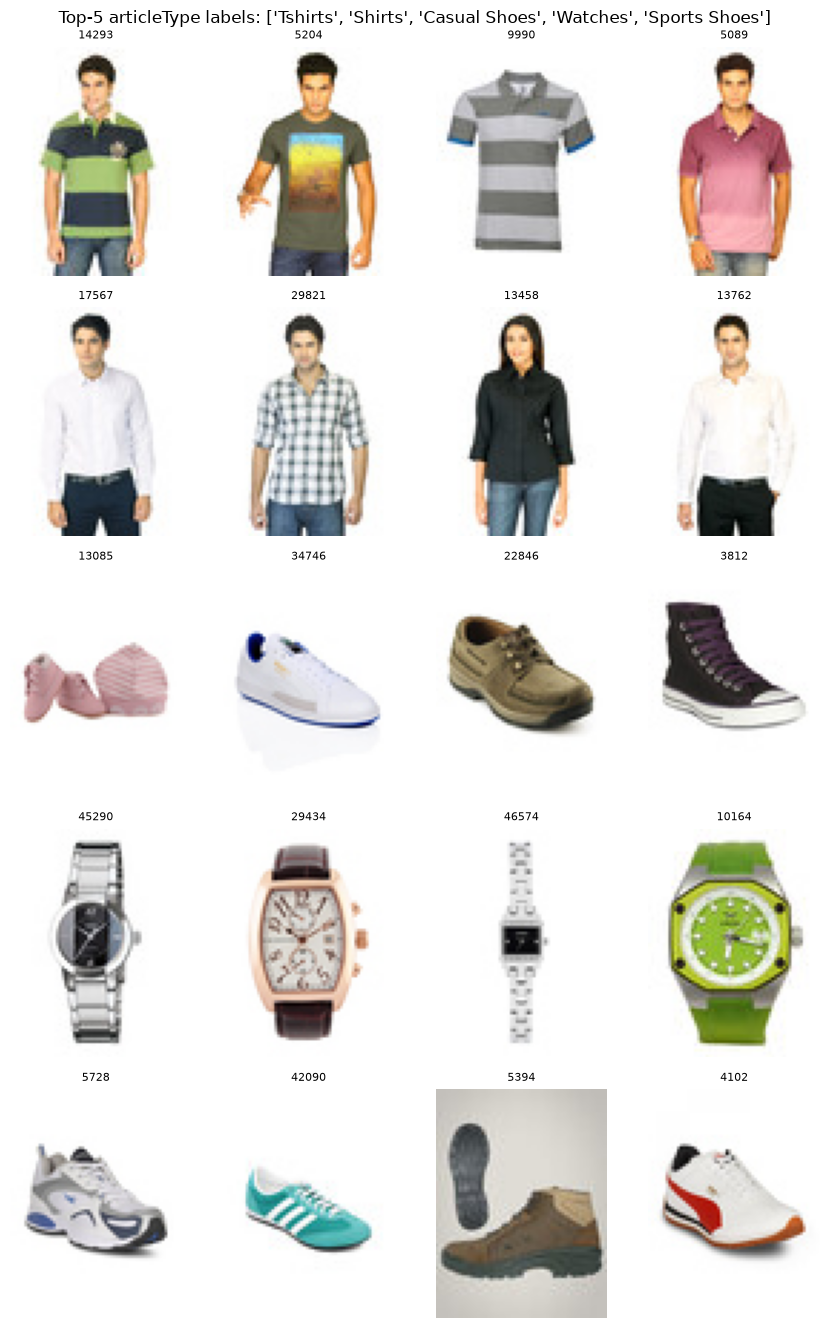

In [24]:
top5_labels = article_type_distribution.head(5)["label"].tolist()
top5_ids = sample_ids(usable_styles, "articleType", top5_labels, per_label=4, seed=RANDOM_SEED)
top5_figure = plot_image_grid(top5_ids, TRAIN_IMAGE_DIR, f"Top-5 articleType labels: {top5_labels}", columns=4)
plt.show()
plt.close(top5_figure)

**Interpretation.** These are the classes a majority-baseline or an under-trained model
will default to; visually confirming they are coherent (same garment, consistent framing)
rules out "the majority class is itself a mislabeled grab-bag" as an explanation for a
model leaning on it.

### 5.2 Every singleton and doubleton `articleType`

**Rule:** every `articleType` label with count ≤ 2 in the raw CSV (from
`article_type_distribution`), up to 2 images per label, sampled from `usable_styles` via
`sample_ids(..., seed=RANDOM_SEED)`. This covers all such labels in one grid because there
are few enough to stay readable. Labels are taken from the raw distribution so the rare-label
list stays complete, but images come from the usable population, so a label with no usable
image is reported by name instead of being silently dropped.

15 articleType labels have count <= 2 in the raw CSV: ['Baby Dolls', 'Concealer', 'Key chain', 'Lehenga Choli', 'Rain Jacket', 'Rain Trousers', 'Robe', 'Shapewear', 'Body Wash and Scrub', 'Cushion Covers', 'Ipad', 'Lounge Tshirts', 'Shoe Laces', 'Suits', 'Ties and Cufflinks']
rare labels with zero usable images (no panel below): ['Suits']
panels shown: 22 images across 14 labels


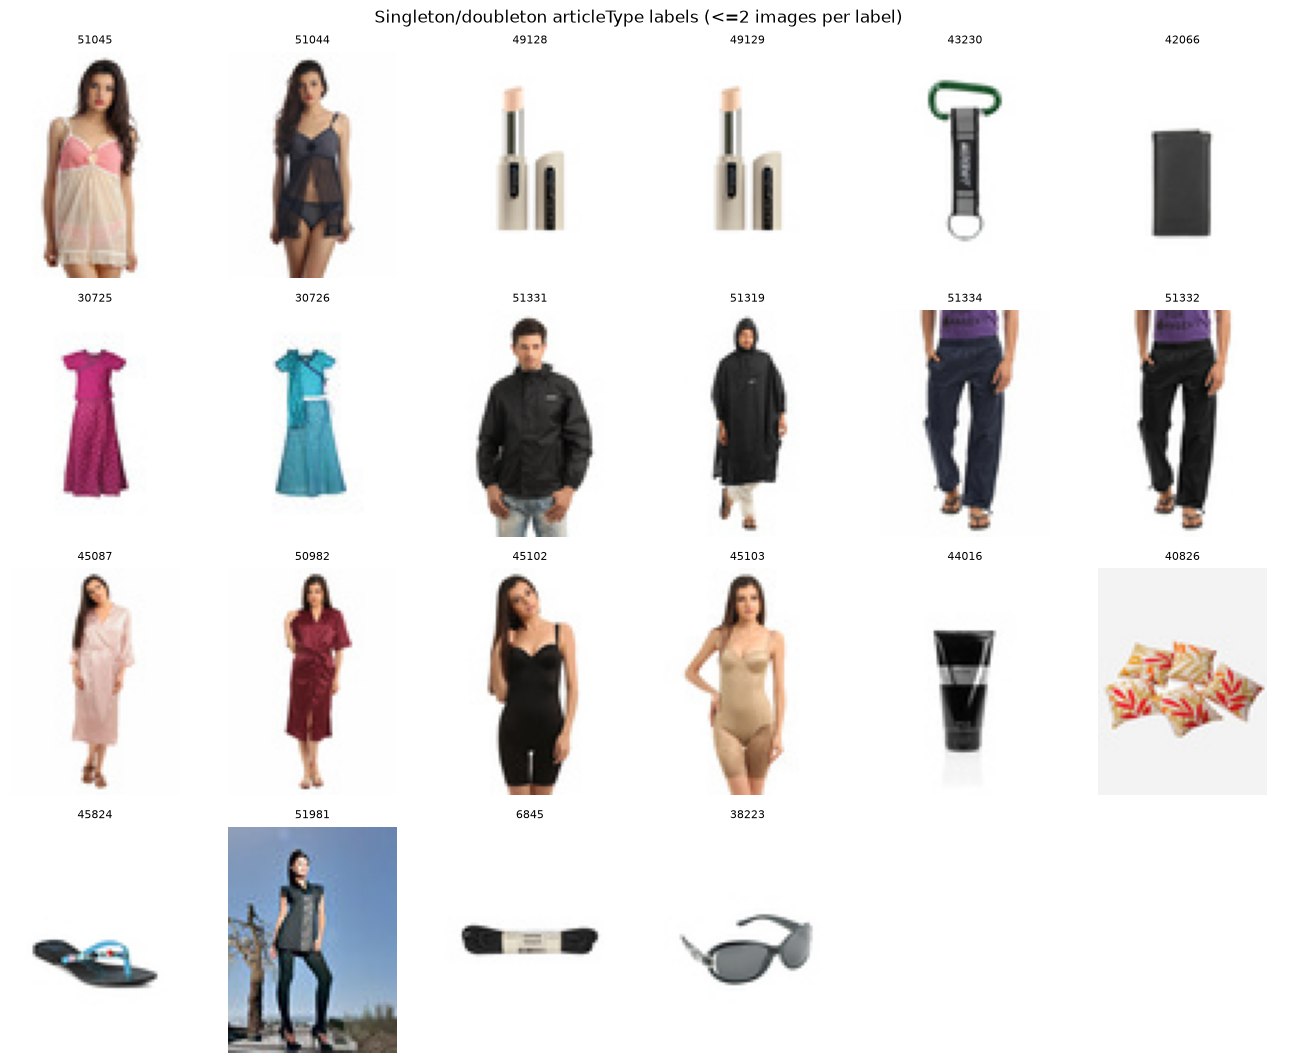

In [25]:
rare_labels = article_type_distribution.loc[article_type_distribution["count"].le(2), "label"].tolist()
print(f"{len(rare_labels)} articleType labels have count <= 2 in the raw CSV: {rare_labels}")

# Sampled from usable_styles, so a label whose only row has no image contributes no panel.
rare_ids = sample_ids(usable_styles, "articleType", rare_labels, per_label=2, seed=RANDOM_SEED)
rare_usable_counts = (
    usable_styles.loc[usable_styles["articleType"].isin(rare_labels), "articleType"]
    .value_counts()
    .reindex(rare_labels)
    .fillna(0)
    .astype(int)
)
unshowable_labels = rare_usable_counts[rare_usable_counts.eq(0)].index.tolist()
print(f"rare labels with zero usable images (no panel below): {unshowable_labels}")
print(f"panels shown: {len(rare_ids)} images across {len(rare_labels) - len(unshowable_labels)} labels")
rare_figure = plot_image_grid(rare_ids, TRAIN_IMAGE_DIR, "Singleton/doubleton articleType labels (<=2 images per label)", columns=6)
plt.show()
plt.close(rare_figure)

**Interpretation.** A singleton class cannot appear in both a training split and an
evaluation split at once, so it can never be *fairly* evaluated no matter how it is
trained; a doubleton can support at most one training example and one evaluation example,
with zero margin for a validation slice. Whether these images look like genuine rare
products or like annotation noise (e.g. a one-off mislabel of a common garment) is a
judgment call notebook `01` must make per label — this grid is the evidence for that call,
not the call itself.

**Two of the singletons are visibly mislabelled, and their own metadata agrees.** Id
`38223` is filed as `articleType = Ties and Cufflinks` with `subCategory = Cufflinks`, but
the panel shows sunglasses and its name is "Polaroid Women Sunglasses". Id `45824` is filed
as `Ipad` under `subCategory = Vouchers`, but the panel shows a pair of flats and its name
is "Senorita Women Blue Flats". In both cases the image, the product name and the
subCategory agree with each other and disagree with `articleType`, so these are not rare
products — they are annotation errors that happen to have created a class of size one.
That matters for the rare-class policy: some singleton classes are not worth preserving at
all, and a rule that mechanically keeps or drops every low-support class will get these
wrong either way. It does *not* make the rows worthless — their `gender`, `season` and
`usage` labels look fine, which is the same target-specific principle as Section 5.4.

**`Suits` has no panel, and the reason matters.** Its single row is id `12347`, one of the
five CSV rows with no image file (Section 2.2), so the class has one row in the CSV and
zero usable examples. It cannot be trained, evaluated, or even *looked at* — which is why
Section 6 counts it separately from the six genuine singletons rather than lumping it in.
Its `productDisplayName` is "Fastrack Men Red Manhattan Regular Fit Solid Formal Shirt",
which describes a shirt rather than a suit, so the label itself looks like annotation
noise. That is a suggestive reading of the text, not a verified finding: with no image,
nothing here can confirm it.

### 5.3 Hierarchy-conflict label samples

**Rule:** the 8 highest-support labels from `hierarchy_issues` (of 20 total, all listed in
Section 4.2), 2 images per label via `sample_ids(..., seed=RANDOM_SEED)` — capped to 8
labels so the grid stays readable; the full conflict list remains in the table above.

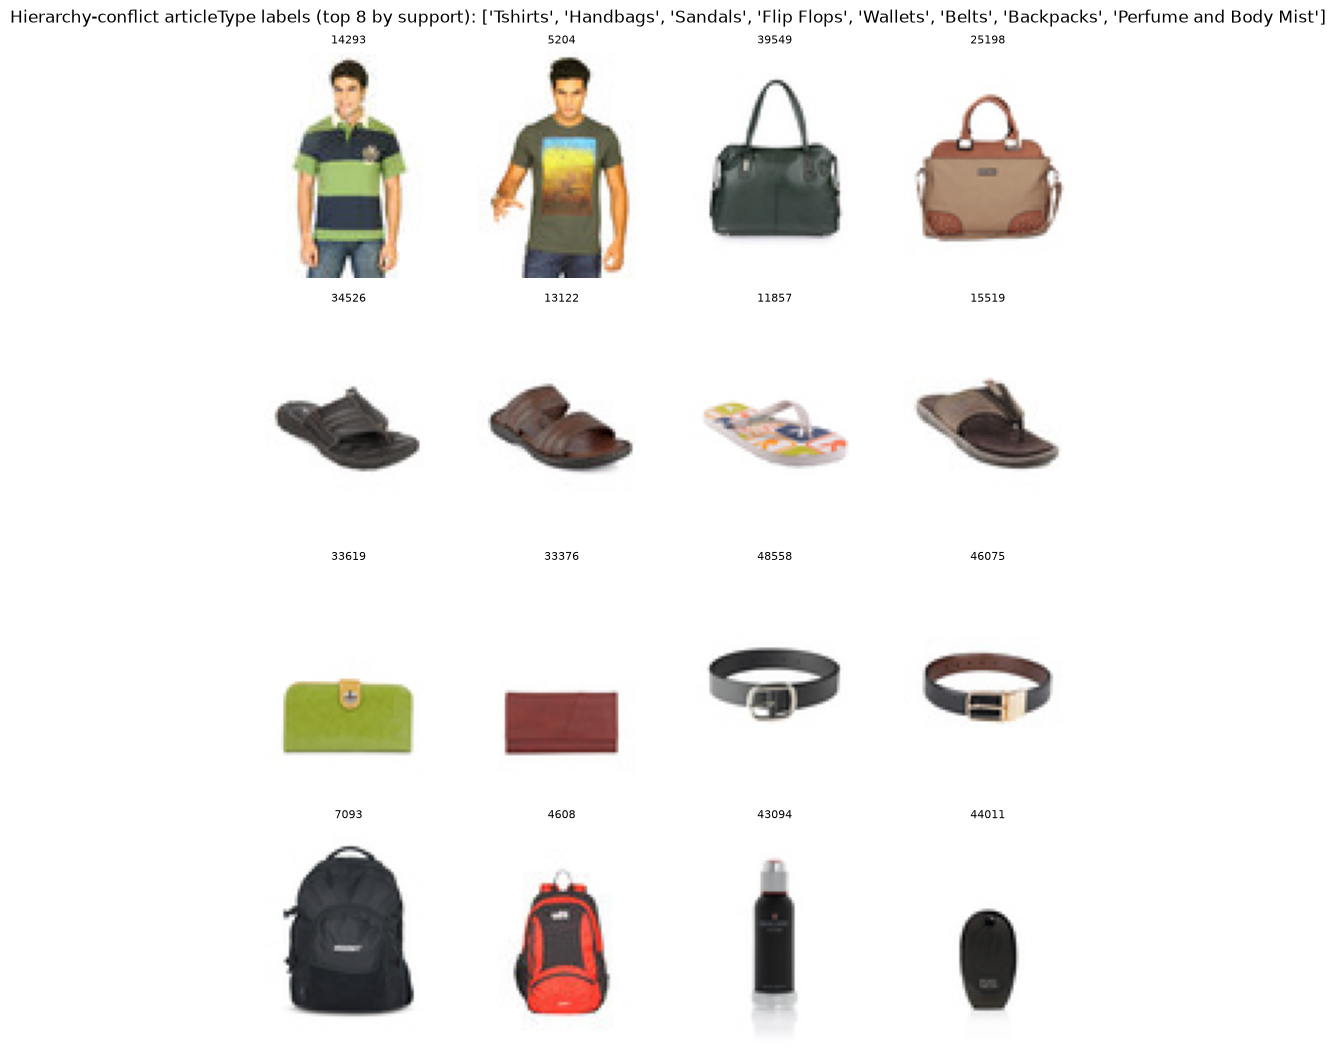

In [26]:
conflict_labels = hierarchy_issues.sort_values("rows", ascending=False).head(8)["articleType"].tolist()
conflict_ids = sample_ids(usable_styles, "articleType", conflict_labels, per_label=2, seed=RANDOM_SEED)
conflict_figure = plot_image_grid(conflict_ids, TRAIN_IMAGE_DIR, f"Hierarchy-conflict articleType labels (top 8 by support): {conflict_labels}", columns=4)
plt.show()
plt.close(conflict_figure)

**Interpretation.** For each label above, compare what the image actually shows against
the multiple `masterCategory`/`subCategory` values recorded for that `articleType` in
Section 4.2. Where the image plausibly fits either category (e.g. a belt-like accessory
also filed as topwear trim) the conflict looks like a genuine dual-use product; where the
image obviously belongs to one category and the other assignment looks like a fat-finger
label, it is annotation noise. This grid cannot resolve every label — it demonstrates the
*kind* of evidence needed before notebook `01` picks a hierarchy-repair policy.

### 5.4 Blank targets and literal `usage == "NA"`

**Rule:** all rows with blank `season`, the single blank `usage` row, and up to 10 rows
with literal `usage == "NA"`, sampled via `sample_ids(..., seed=RANDOM_SEED)`.

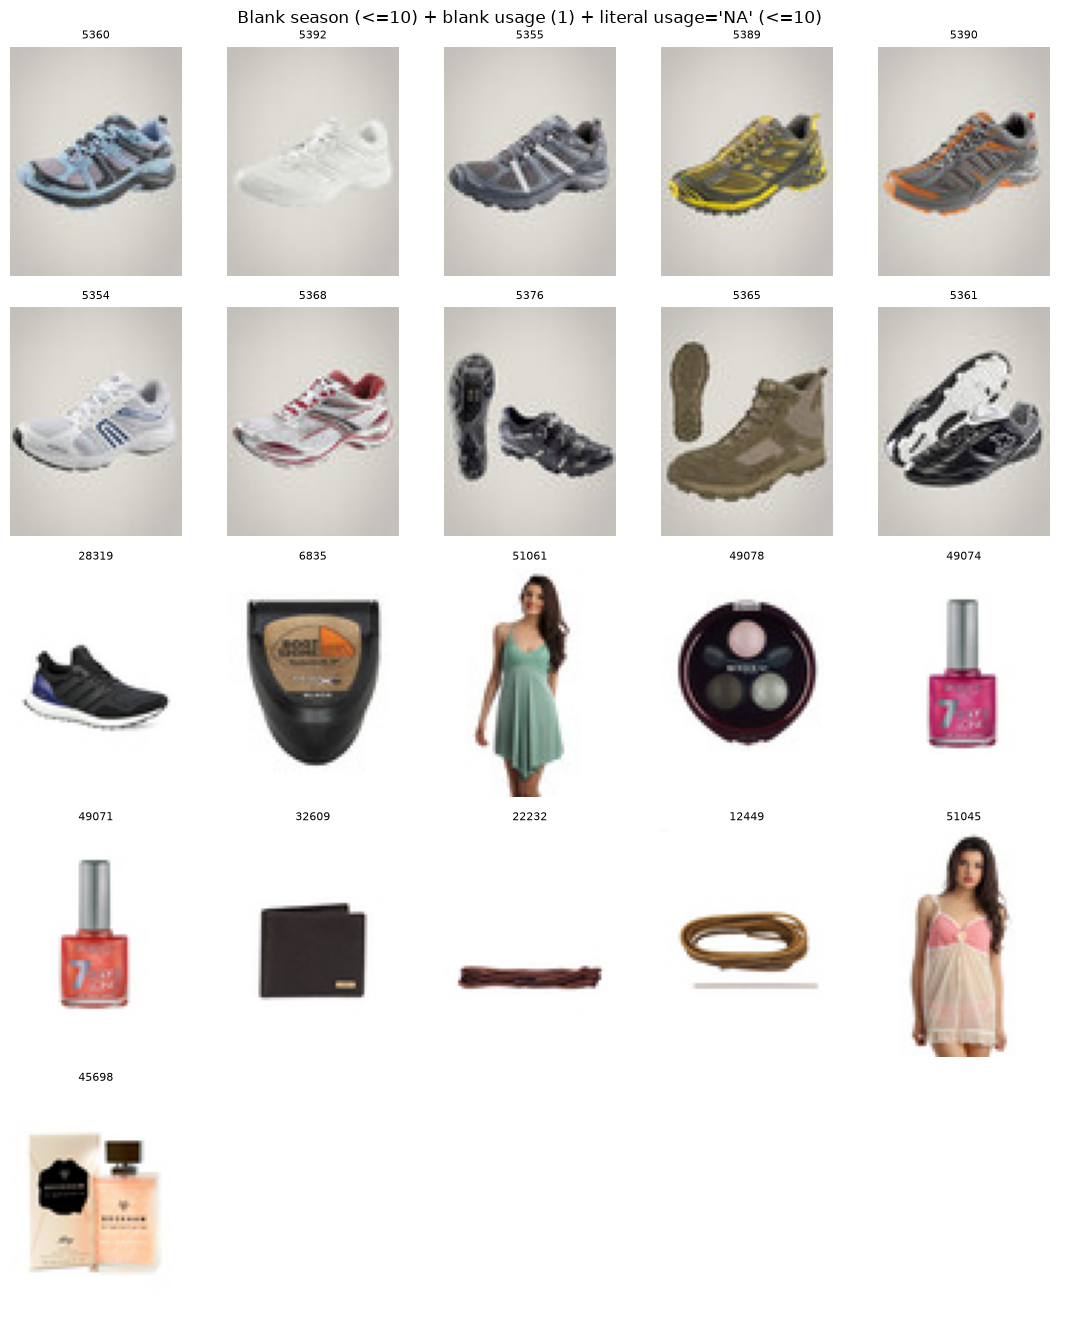

In [27]:
blank_season_ids = sample_ids(usable_styles, "season", ["<BLANK>"], per_label=10, seed=RANDOM_SEED)
blank_usage_ids = sample_ids(usable_styles, "usage", ["<BLANK>"], per_label=1, seed=RANDOM_SEED)
na_usage_ids = sample_ids(usable_styles, "usage", ["NA"], per_label=10, seed=RANDOM_SEED)
missing_label_ids = blank_season_ids + blank_usage_ids + na_usage_ids
missing_figure = plot_image_grid(
    missing_label_ids,
    TRAIN_IMAGE_DIR,
    "Blank season (<=10) + blank usage (1) + literal usage='NA' (<=10)",
    columns=5,
)
plt.show()
plt.close(missing_figure)

**Interpretation.** Blank `season` and blank `usage` are missing annotations — the
product is simply unrated for that target. Literal `usage == "NA"` is different: an
annotator explicitly recorded "not applicable" rather than leaving the field empty, which
Section 4.1's distribution already counts separately from blanks. Because missingness is
target-specific, a row with a blank `season` can still carry a perfectly usable `gender`
or `articleType` label — notebook `01` must not drop these rows from every task just
because one target is unrated.

### 5.5 Pixel-exact duplicate groups

**Rule:** the first 3 of the confirmed pixel-identical groups (deterministic order from
`exact_duplicate_groups`, no randomness needed since the grouping itself is fully
deterministic), every member shown.

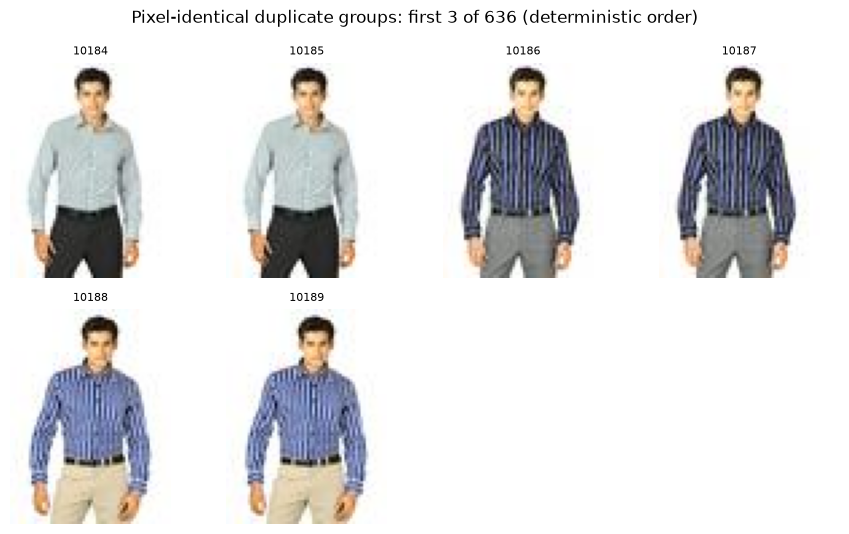

In [28]:
sampled_exact_groups = pixel_duplicate_groups[:3]
exact_sample_ids = [image_id for group in sampled_exact_groups for image_id in group]
exact_figure = plot_image_grid(
    exact_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Pixel-identical duplicate groups: first 3 of {len(pixel_duplicate_groups)} (deterministic order)",
    columns=4,
)
plt.show()
plt.close(exact_figure)

**Interpretation.** These groups are confirmed, not candidates — the pixel hash proves
byte-for-byte identical decoded content. Visual review here is a plausibility check on
the hashing pipeline, not a confirmation step; every group in `exact_groups_table` (all
636, not only these 3) must be treated as atomic for splitting regardless of what the
sample looks like.

### 5.6 Near-duplicate candidate groups

**Rule (typical case):** a seeded random sample of 3 pair-sized (`size == 2`) candidate
groups — the modal group size — using `random.Random(RANDOM_SEED)`, every member shown.

**Rule (large candidates):** the two largest *retained* components under Section 3.3's
quarantine rule, deterministic order, first 6 members of each (sorted IDs).

**Rule (giant component):** the first 12 (sorted) IDs from the single quarantined
component, to show what transitive chaining actually produced.

These caps bound how many images are rendered, not how much evidence exists: Section 3.3
records every retained component's complete membership by ID, and the cell after the grids
below tabulates the *complete* label and brand composition of both large components. Six
thumbnails cannot characterise a 189-member group, so every claim in the commentary is
drawn from those full tables rather than from the panels.

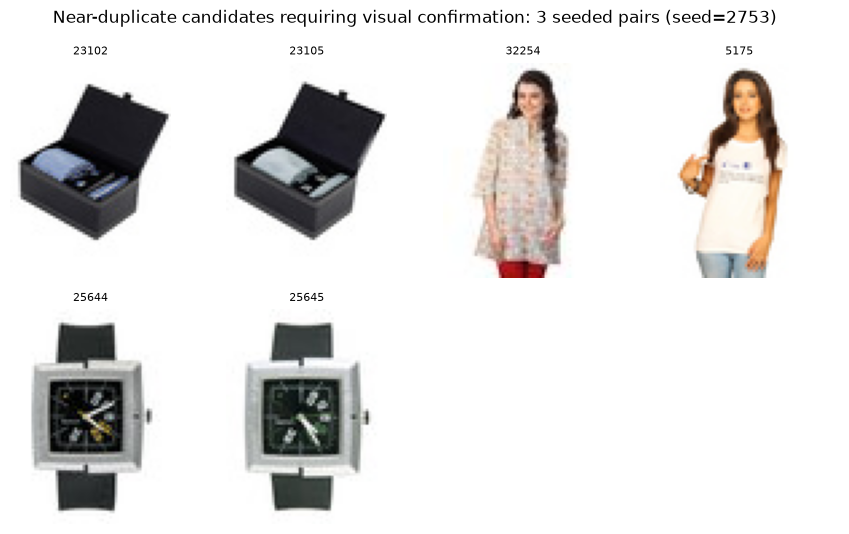

In [29]:
import random

pair_groups = [group for group in near_groups if len(group) == 2]
seeded_pairs = random.Random(RANDOM_SEED).sample(pair_groups, k=min(3, len(pair_groups)))
pair_sample_ids = [image_id for group in seeded_pairs for image_id in group]
pair_figure = plot_image_grid(
    pair_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Near-duplicate candidates requiring visual confirmation: 3 seeded pairs (seed={RANDOM_SEED})",
    columns=4,
)
plt.show()
plt.close(pair_figure)

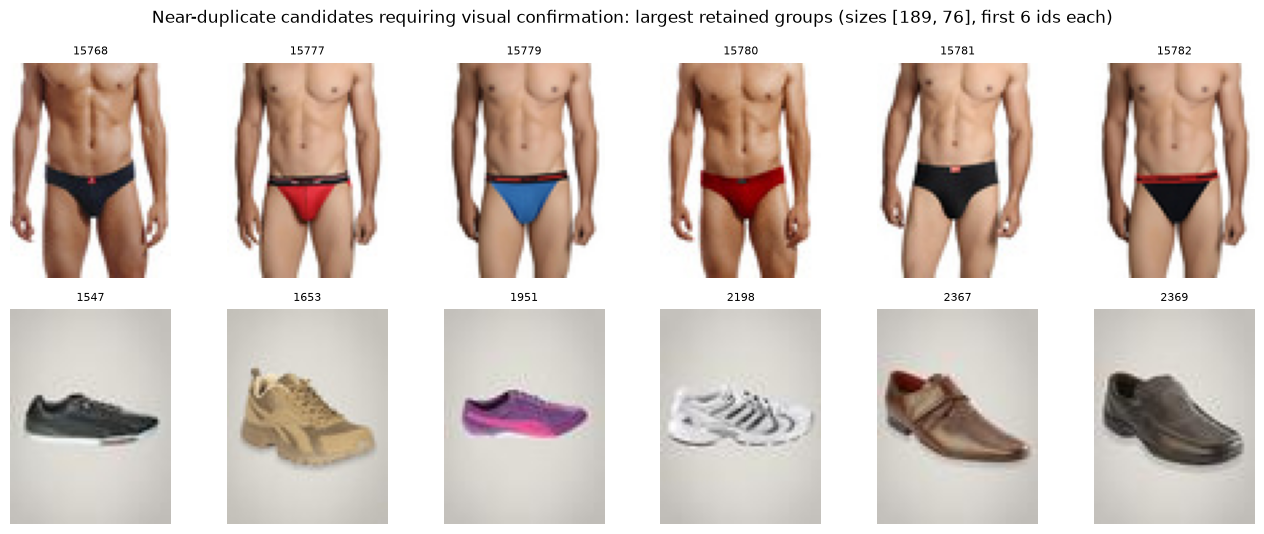

In [30]:
large_candidate_groups = sorted(retained_groups, key=len, reverse=True)[:2]
large_sample_ids = [image_id for group in large_candidate_groups for image_id in sorted(group)[:6]]
large_figure = plot_image_grid(
    large_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Near-duplicate candidates requiring visual confirmation: largest retained groups (sizes {[len(g) for g in large_candidate_groups]}, first 6 ids each)",
    columns=6,
)
plt.show()
plt.close(large_figure)

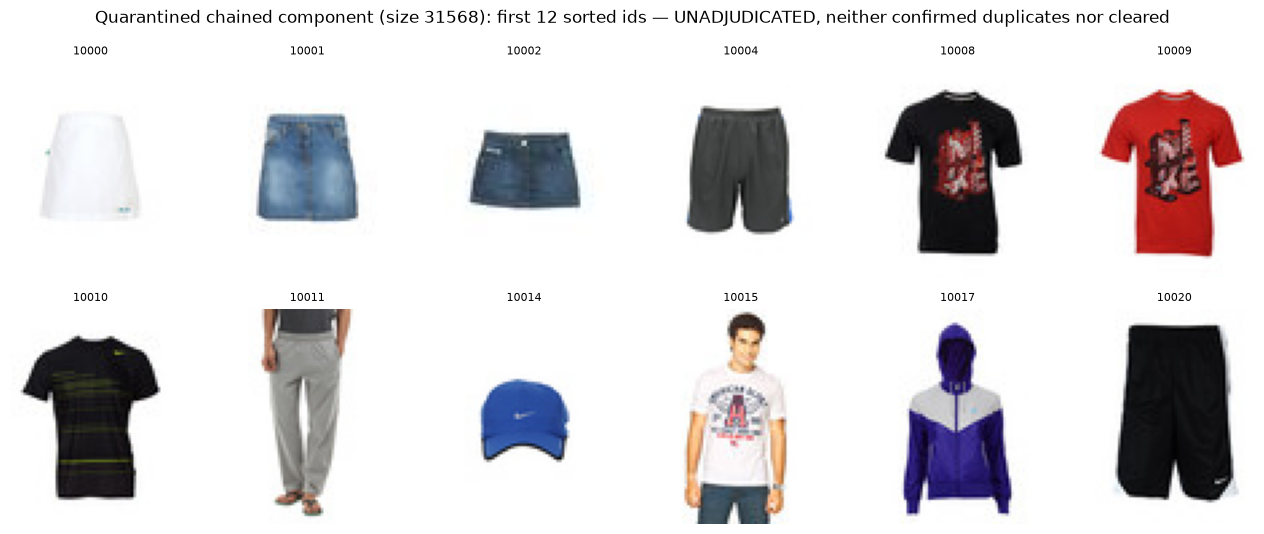

In [31]:
giant_sample_ids = sorted(giant_component)[:12]
giant_figure = plot_image_grid(
    giant_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Quarantined chained component (size {len(giant_component)}): first 12 sorted ids — UNADJUDICATED, neither confirmed duplicates nor cleared",
    columns=6,
)
plt.show()
plt.close(giant_figure)

In [32]:
def component_composition(
    group: tuple[str, ...],
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    """Complete label/brand composition of one component — every member, not a sample."""
    members = styles.loc[styles["id"].astype(str).isin(set(group))]
    # The CSV has no brand column; the first whitespace token of productDisplayName is a
    # rough stand-in, so it is named brand_proxy and never treated as ground truth.
    brand_proxy = members["productDisplayName"].astype(str).str.split().str[0]
    article_counts = members["articleType"].value_counts()
    brand_counts = brand_proxy.value_counts()
    return members, article_counts, brand_counts


for group in large_candidate_groups:
    members, article_counts, brand_counts = component_composition(group)
    print(f"===== component of {len(group)} images ({len(members)} metadata rows) =====")
    print(f"distinct articleType: {article_counts.size}   distinct brand_proxy: {brand_counts.size}")
    print(f"masterCategory: {dict(members['masterCategory'].value_counts())}")
    print(f"gender: {dict(members['gender'].value_counts())}")
    print("-- complete articleType counts --")
    print(article_counts.to_string())
    print("-- complete brand_proxy counts (first token of productDisplayName) --")
    print(brand_counts.to_string())
    print()

===== component of 189 images (189 metadata rows) =====
distinct articleType: 3   distinct brand_proxy: 14
masterCategory: {'Apparel': np.int64(189)}
gender: {'Men': np.int64(189)}
-- complete articleType counts --
articleType
Briefs    147
Trunk      36
Boxers      6
-- complete brand_proxy counts (first token of productDisplayName) --
productDisplayName
Chromozome     65
Facit          39
Park           25
FCUK           17
Hanes          13
Levis           8
Playboy         5
Calvin          5
Myntra          4
Basics          3
Crusoe          2
Undercolors     1
Probase         1
Parx            1

===== component of 76 images (76 metadata rows) =====
distinct articleType: 7   distinct brand_proxy: 15
masterCategory: {'Footwear': np.int64(76)}
gender: {'Men': np.int64(51), 'Women': np.int64(17), 'Unisex': np.int64(7), 'Girls': np.int64(1)}
-- complete articleType counts --
articleType
Casual Shoes    35
Flip Flops      16
Formal Shoes     8
Sports Shoes     7
Sandals          6
Fl

**Interpretation.** The three seeded pairs land in three different states, which is exactly
why nothing here is auto-accepted.

- Ids `25644`/`25645` carry **the same `productDisplayName`** ("Fastrack Men Black Casual
  Watch") and the same `baseColour`. Two catalogue rows for one product is the most likely
  reading, so this is a probable duplicate *listing* rather than a colourway pair — and a
  human should confirm it and keep the two rows together.
- Ids `23102`/`23105` are two different products (a blue tie-and-cufflink set and a grey
  gift set) shot in the same box, at the same angle, under the same lighting. Not
  duplicates; near-identical images.
- Ids `32254`/`5175` are a printed kurti and a plain white t-shirt, unrelated garments
  sharing only a full-length female model on white. A pure `dhash` collision: at 60×80 the
  hash encodes pose and background far more strongly than the garment.

**The two large components are photographic template clusters, and the complete tables above
say so far more strongly than the six thumbnails do.** The 189-member component is not one
brand's product line: it spans three labels (`Briefs` 147, `Trunk` 36, `Boxers` 6) and
fourteen `brand_proxy` values (Chromozome 65, Facit 39, Park 25, FCUK 17, Hanes 13, Levis 8,
and eight more), every row `Men`/`Apparel`. What binds it is the shoot, not the product: the
same male torso, same crop, same lighting, with only the garment changing. The 76-member
component is the same phenomenon in footwear — seven labels (`Casual Shoes` 35, `Flip Flops`
16, `Formal Shoes` 8, `Sports Shoes` 7, `Sandals` 6, `Flats` 3, `Heels` 1), fifteen brand
proxies, and mixed gender (51 Men, 17 Women, 7 Unisex, 1 Girls) — bound by one shoe on a
grey background. Note how badly a six-image sample misleads here: the six briefs panels are
all Facit, which is 39 of 147 briefs and none of the 42 trunks and boxers.

**The leakage implication is stronger than "duplicates leak".** A shared template spanning
labels and brands means the constant part of the image is *uninformative* about the target
while being highly predictive of which images are template-mates. Split those members
across a boundary and the evaluation set contains images whose backgrounds, crops and
lighting the model has already memorised, inflating scores without any transfer to a new
shoot. For Task 4 retrieval it is worse: nearest-neighbour search will happily return
template-mates — a Chromozome trunk retrieved for a Hanes brief — because the template
dominates the embedding. So these components must stay atomic even though **they are not
duplicates**, and they need their own ledger disposition rather than being forced into the
duplicate/not-duplicate dichotomy.

**No group on this page is auto-accepted.** Only a human explicitly marking a specific
group as confirmed (recorded outside this notebook) may turn it into an atomic split unit;
everything here remains a candidate, and the collision above is the concrete reason why.

## 6. Split-Feasibility and Open-Decision Evidence

Before any split exists, we can already say which labels *could* support one. The right
question is not "how many CSV rows carry this label" but **"how many rows carry it *and*
have an image a model can load"** — a label with rows but no images is worth exactly zero
to an image classifier. So the table below counts the usable population from Section 2.2,
and reports the raw count beside it so the gap is visible rather than hidden.

The table also refuses to grade `<BLANK>`. A blank is a missing annotation, not a class
anyone will predict, so scoring its "coverage" would invent a 126th `articleType` or a 6th
`season`; it is labelled as missing annotation and excluded from the class-coverage bands.

In [33]:
def evaluation_status(usable_count: int) -> str:
    if usable_count == 0:
        return "no usable image; cannot be trained or evaluated"
    if usable_count == 1:
        return "cannot appear in both training and evaluation"
    if usable_count == 2:
        return "cannot support train/validation/held-out coverage"
    if usable_count <= 4:
        return "coverage possible but metric unstable"
    return "eligible for coverage checks"


feasibility_rows = []
for target in TARGET_COLUMNS:
    raw_counts = target_distribution(styles, target).set_index("label")["count"]
    usable_counts = (
        target_distribution(usable_styles, target)
        .set_index("label")["count"]
        .reindex(raw_counts.index)
        .fillna(0)
        .astype(int)
    )
    for label in raw_counts.index:
        usable_count = int(usable_counts[label])
        feasibility_rows.append(
            {
                "target": target,
                "label": label,
                "count": int(raw_counts[label]),
                "usable_count": usable_count,
                "lost_to_missing_images": int(raw_counts[label]) - usable_count,
                "evaluation_status": (
                    "missing annotation, not a class"
                    if label == "<BLANK>"
                    else evaluation_status(usable_count)
                ),
            }
        )
support_feasibility = pd.DataFrame(feasibility_rows)
print(support_feasibility.to_string(index=False))

     target                 label  count  usable_count  lost_to_missing_images                                 evaluation_status
articleType               Tshirts   6781          6780                       1                      eligible for coverage checks
articleType                Shirts   3089          3087                       2                      eligible for coverage checks
articleType          Casual Shoes   2683          2683                       0                      eligible for coverage checks
articleType               Watches   2252          2252                       0                      eligible for coverage checks
articleType          Sports Shoes   1991          1991                       0                      eligible for coverage checks
articleType                  Tops   1614          1614                       0                      eligible for coverage checks
articleType                Kurtas   1556          1556                       0                   

In [34]:
print("-- label counts by evaluation status (usable population) --")
print(support_feasibility["evaluation_status"].value_counts().to_string())

print("\n-- every label whose usable count differs from its raw count --")
print(
    support_feasibility.loc[support_feasibility["lost_to_missing_images"].gt(0)]
    .sort_values(["lost_to_missing_images", "target", "label"], ascending=[False, True, True])
    .to_string(index=False)
)

print("\n-- every label that is not 'eligible for coverage checks' --")
print(
    support_feasibility.loc[
        support_feasibility["evaluation_status"].ne("eligible for coverage checks")
    ].to_string(index=False)
)

headline = pd.DataFrame(
    {
        "population": ["raw CSV rows", "usable rows (matched id, readable image)"],
        "rows": [len(styles), len(usable_styles)],
        "articleType classes present": [
            int(styles["articleType"].nunique()),
            int(usable_styles["articleType"].nunique()),
        ],
    }
)
print("\n-- headline populations --")
print(headline.to_string(index=False))

-- label counts by evaluation status (usable population) --
evaluation_status
eligible for coverage checks                         120
cannot support train/validation/held-out coverage      8
coverage possible but metric unstable                  7
cannot appear in both training and evaluation          7
missing annotation, not a class                        2
no usable image; cannot be trained or evaluated        1

-- every label whose usable count differs from its raw count --
     target   label  count  usable_count  lost_to_missing_images                               evaluation_status
     gender     Men  20918         20913                       5                    eligible for coverage checks
      usage  Casual  29641         29636                       5                    eligible for coverage checks
articleType  Shirts   3089          3087                       2                    eligible for coverage checks
     season  Summer  19137         19135                       

**Evidence-bound conclusions for notebook `01`:**

- CSV rows without readable images (Section 2.2's `csv_only` set) cannot be used by image
  models, regardless of how good their labels are. Concretely: 38,617 CSV rows become
  38,612 usable rows, and `articleType` drops from 125 classes to 124, because `Suits`
  loses its only row. Any feasibility statement computed on the raw frame overstates what
  is trainable — that is not a rounding difference for a singleton class, it is the
  difference between "hard" and "impossible".
- One label, `Suits`, has zero usable images and is reported in its own status band rather
  than being counted as a trainable singleton.
- Phantom columns (Section 2.1) carry no model information; they only recorded raw-CSV
  overflow that `audit_csv` already folded back into `productDisplayName`.
- Missingness is target-specific (Section 4.1/5.4): notebook `01` must not discard a row
  for every task just because one target's label is blank.
- Confirmed duplicate groups (Section 3.1) must remain atomic — never split across
  training and evaluation.
- Photographic template clusters (Section 5.6) must also remain atomic, for a different
  reason: they are *not* duplicates, but their shared shoot spans labels and brands, so
  splitting them leaks memorised background and crop into evaluation and pollutes
  retrieval neighbourhoods.
- The quarantined 31,568-image component (Section 3.3) is unadjudicated evidence, not a
  cleared set. Notebook `01` must either re-cluster it at a tighter distance or state, with
  numbers, how much residual leakage it is accepting.
- The rare-`articleType` policy (Section 5.2, and the `"1"`/`"2"` rows above) remains
  **unresolved**: notebook `01` must explicitly state whether task-level exclusion of
  singleton/doubleton classes, or merging them into a coarser hierarchy level, preserves
  the assignment's actual target most honestly — this notebook only supplies the evidence,
  not the ruling.
- Shared `gender`/`usage` learning (Section 4.3) remains a **controlled experiment**, not
  an EDA conclusion. The measured Cramér's V of 0.2071 is a weak association: it is enough
  to make the comparison worth running and not enough to predict its outcome.
- Visual-search relevance (Task 4 of the assignment) has no human relevance labels, so any
  Top-K evaluation must compare **at least** exact `articleType` match, shared
  `subCategory` match, and one documented hierarchical rule as competing relevance
  definitions, and report all three rather than picking one silently.

## 7. Dataset Overview Figure and Decision Ledger

The only figure this notebook saves to disk: a four-panel composite summarising the
`articleType` long tail and the `season`/`gender`/`usage` distributions, annotated with
per-bar counts and a headline summary of readable images and unmatched IDs.

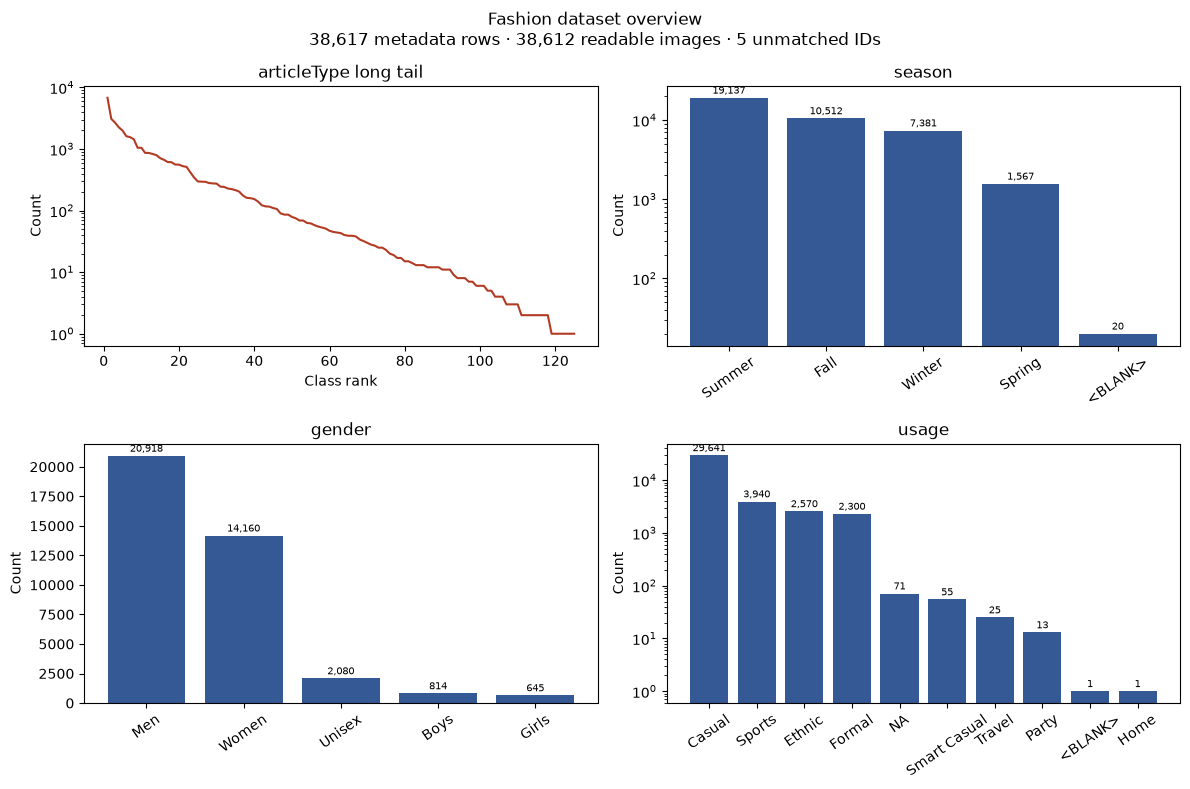

Saved /Users/lintran/Documents/Coding/MLA2/results/figures/dataset_overview.png (177,656 bytes)


In [35]:
overview_path = FIGURE_DIR / "dataset_overview.png"
overview_figure = build_dataset_overview(styles, images, overview_path)
plt.show()
plt.close(overview_figure)
assert overview_path.is_file()
print(f"Saved {overview_path} ({overview_path.stat().st_size:,} bytes)")

### Decision ledger

| Decision | Evidence | Status | Downstream rule | Follow-up |
|---|---|---|---|---|
| CSV parsing must preserve literal `"NA"` | Section 2.1 schema fields; `literal_na_usage_count` ≠ `blank_counts["usage"]` | Resolved | Always read `styles_train.csv`/`styles_prediction.csv` with `keep_default_na=False` | None |
| Phantom `Unnamed:` columns hold real overflow text | Section 2.1 `phantom_nonempty_counts` | Resolved | Reconstruct `productDisplayName` from phantom columns in memory; never treat phantom columns as model features | None |
| Unmatched CSV/image IDs must be excluded from image pipelines | Section 2.2 `unmatched_ids`, `reconciliation_summary`, `usable_styles` | Resolved | Every image-model computation and every feasibility count uses `usable_styles` (38,612 rows), never the raw 38,617; `articleType` therefore has 124 usable classes, not 125 | Confirm the held-out test set (`data/test/`) has the same or a different mismatch profile before reusing this logic there |
| `Suits` has metadata but no image | Section 2.2 unusable rows, Section 5.2, Section 6 `usable_count` | Resolved | Treat as untrainable and unevaluable; never report it as a learnable singleton class | Its display name reads "…Formal Shirt", so if a later task recovers the image, re-check the label before using it |
| Image corruption handling | Section 2.2 `corrupt_images` (empty; all 38,612 files decoded) | Resolved for this dataset; branch untested | Loader must still catch `OSError`/`UnidentifiedImageError` defensively, because zero failures here proves nothing about `data/test/` | Audit the test image set the same way before trusting it |
| Dimensions/modes are not uniformly `60×80` RGB | Section 2.2 `dimension_mode_counts` | Resolved (documented, not fixed here) | Preprocessing must resize/convert to a single canonical shape and mode before batching | None |
| **Disposition 1 —** confirmed exact duplicate groups | Section 3.1 `exact_groups_table`; byte and pixel partitions equal | Resolved | All 636 groups (1,399 images) are atomic split units, no human review needed | None |
| **Disposition 2 —** human-confirmed near duplicates | Section 3.3 inventory, Section 5.6 grids (e.g. ids 25644/25645, same `productDisplayName`) | Unresolved by design | A group becomes atomic only once a human accepts it; hash proximity alone never promotes it | Work the 447-component queue in Section 3.3 and record each accept/reject outside this notebook |
| **Disposition 3 —** photographic template clusters (not duplicates, still atomic) | Section 5.6 complete composition tables: 189 images across 3 labels/14 brand proxies; 76 images across 7 labels/15 brand proxies | Resolved as a category; membership still needs review | Keep template-mates on one side of the split even though the products differ, because the shared shoot — not the garment — is what a model would memorise | Decide whether template clusters are also excluded from Task 4 retrieval ground truth, since they pollute nearest-neighbour results across labels and brands |
| Quarantine threshold for the chained component | Section 3.2 histogram, Section 3.3 printed stability band | Resolved as a rule; the quarantined images are **unadjudicated** | Cut at 1% of readable images; every cutoff from 189 to 31,567 gives the identical partition — under `len(group) <= cutoff`, 189 still retains the 189-member component and 31,568 would retain the giant one, so the number is a size gap, not a product-identity claim. Consequence: 31,568 images (81.8% of readable, 95.3% of all linked) leave the review queue without a verdict | Before finalising the split, either re-cluster the quarantined component at a tighter Hamming distance (or with intra-component clustering) or state in writing, with numbers, how much residual leakage risk is being accepted |
| Missing labels are target-specific | Section 4.1, Section 5.4 | Resolved | Do not drop a row for every task because one target is blank | None |
| Rare `articleType` classes (singleton/doubleton/long tail) | Section 4.1 support buckets, Section 5.2, Section 6 usable counts | Unresolved | Notebook `01` must choose task-level exclusion vs. hierarchy merging and justify it; the population it counts is `usable_styles`, where 6 labels are true singletons and 1 (`Suits`) has nothing at all | Decide and document in notebook `01`. Note that at least two singletons (`Ties and Cufflinks` id 38223, `Ipad` id 45824) are mislabels rather than rare products, so a purely count-based rule will misclassify them; check the label against `productDisplayName` and `subCategory` before preserving a singleton class |
| Split balance / support feasibility | Section 6 `support_feasibility` (`count` vs `usable_count`) | Resolved (evidence only) | Any label whose `evaluation_status` is not "eligible for coverage checks" needs an explicit split-design decision; `<BLANK>` rows are missing annotations and are never graded as classes | Notebook `01` split design must consult this table per target, reading `usable_count` |
| `gender`/`usage` architecture (shared vs. independent heads) | Section 4.3 `gender_usage_v` = 0.2071 | Unresolved by design | A weak association neither justifies nor rules out a shared model | Run a controlled independent-vs-multitask comparison in the modelling notebooks |
| Visual-search retrieval relevance definition | Section 6 conclusions | Unresolved | No single relevance definition is assumed | Task 4 notebook must report Top-K metrics under exact `articleType`, shared `subCategory`, and one documented hierarchical rule |